# Assignment 6: Simulating the Ising Model



## Part 1: Code Structure and Setup

### 1.1 Import Required Libraries

In [3]:
# Import numpy for array operations and random number generation
import numpy as np

# Import matplotlib for visualization
import matplotlib.pyplot as plt

### 1.2 Initialize Grid of Random Spins

We create a 50×50 grid where each cell randomly contains either +1 (spin up) or -1 (spin down).

In [4]:
# Set random seed for reproducibility
np.random.seed(42)

# Grid size
N = 50

# Initialize grid with random spins (+1 or -1)
# This creates the starting configuration for our simulation
initial_spins = np.random.choice([1, -1], size=(N, N))

print(f"Created a {N}×{N} grid with random spins")
print(f"Grid shape: {initial_spins.shape}")

Created a 50×50 grid with random spins
Grid shape: (50, 50)


### 1.3 Energy Calculation Function

This function calculates the energy change (ΔE) if we flip the spin at position (i,j).  
The formula is: **ΔE = 2 × J × spin[i,j] × (sum of neighbors)**

We use periodic boundary conditions (the grid wraps around like a torus).

In [5]:
def delta_energy(spins, i, j, J=1):
    """
    Calculate the energy change if we flip the spin at position (i, j).
    
    Parameters:
    -----------
    spins : numpy.ndarray
        The current spin configuration (2D array)
    i, j : int
        Position of the spin to flip
    J : float
        Coupling constant (default = 1)
    
    Returns:
    --------
    dE : float
        Energy change if the spin is flipped
    """
    N = spins.shape[0]
    
    # Get the current spin value
    s = spins[i, j]
    
    # Sum of neighboring spins using periodic boundary conditions
    # The % operator ensures wrapping (e.g., -1 % 50 = 49)
    neighbors_sum = (
        spins[(i+1) % N, j] +     # Below
        spins[(i-1) % N, j] +     # Above
        spins[i, (j+1) % N] +     # Right
        spins[i, (j-1) % N]       # Left
    )
    
    # Calculate energy change using the Ising model formula
    dE = 2 * J * s * neighbors_sum
    
    return dE

### 1.4 Metropolis Algorithm Implementation

The Metropolis algorithm is the core of our simulation. For each step:
1. Pick a random spin
2. Calculate ΔE if we flip it
3. Accept the flip if:
   - ΔE < 0 (flip lowers energy), **always accept**
   - ΔE ≥ 0 (flip raises energy), accept with probability exp(-ΔE/T)

This allows the system to reach thermal equilibrium at temperature T.

In [6]:
def metropolis(spins, T, steps, save_snapshots=None):
    """
    Run the Metropolis algorithm to simulate the Ising model.
    
    Parameters:
    -----------
    spins : numpy.ndarray
        Initial spin configuration
    T : float
        Temperature (in units where k_B = 1)
    steps : int
        Number of Monte Carlo steps
    save_snapshots : list or None
        List of step numbers to save snapshots (e.g., [500, 1500, 3000, 5000])
    
    Returns:
    --------
    spins : numpy.ndarray
        Final spin configuration
    snapshots : dict
        Dictionary of snapshots {step_number: spin_configuration}
    """
    N = spins.shape[0]
    snapshots = {}
    
    # Run for the specified number of steps
    for step in range(1, steps + 1):
        # In each step, attempt to flip each spin once on average
        # This is called a "Monte Carlo sweep"
        for _ in range(N * N):
            # Pick a random spin
            i = np.random.randint(0, N)
            j = np.random.randint(0, N)
            
            # Calculate energy change for flipping this spin
            dE = delta_energy(spins, i, j)
            
            # Metropolis acceptance criterion:
            # - If dE < 0, always accept (flip lowers energy)
            # - If dE >= 0, accept with probability exp(-dE/T)
            if dE < 0 or np.random.rand() < np.exp(-dE / T):
                spins[i, j] *= -1  # Flip the spin
        
        # Save snapshot if requested
        if save_snapshots is not None and step in save_snapshots:
            snapshots[step] = spins.copy()
    
    return spins, snapshots

## Part 2: Run Simulation at Different Temperatures

We'll simulate the Ising model at 5 different temperatures:
- **T = 0.5** (very cold - spins strongly prefer to align)
- **T = 1.0** (cold - significant alignment)
- **T = 2.0** (medium - competition between order and disorder)
- **T = 2.5** (warm - thermal fluctuations increasing)
- **T = 4.0** (hot - complete disorder)

Each simulation runs for 5000 steps to ensure equilibration.

In [7]:
# Define temperature values
temperatures = [0.5, 1.0, 2.0, 2.5, 4.0]

# Dictionary to store final states
final_states = {}

print("Running simulations...")
print("-" * 40)

# Run simulation for each temperature
for T in temperatures:
    print(f"Temperature T = {T}...", end=" ")
    
    # Create a fresh random spin configuration for each temperature
    spins_T = np.random.choice([1, -1], size=(N, N))
    
    # Run Metropolis algorithm for 5000 steps
    final_spins, _ = metropolis(spins_T, T, steps=5000)
    
    # Store the final configuration
    final_states[T] = final_spins
    
    print("Done!")

print("-" * 40)
print("All simulations complete!")

Running simulations...
----------------------------------------
Temperature T = 0.5... Done!
Temperature T = 1.0... Done!
Temperature T = 2.0... Done!
Temperature T = 2.5... Done!
Temperature T = 4.0... Done!
----------------------------------------
All simulations complete!


## Part 3: Visualizations

### 3.1 Grid Comparison: Final States at Different Temperatures

This visualization shows how the final spin configuration changes with temperature.  
- **White** represents spin up (+1)
- **Black** represents spin down (-1)

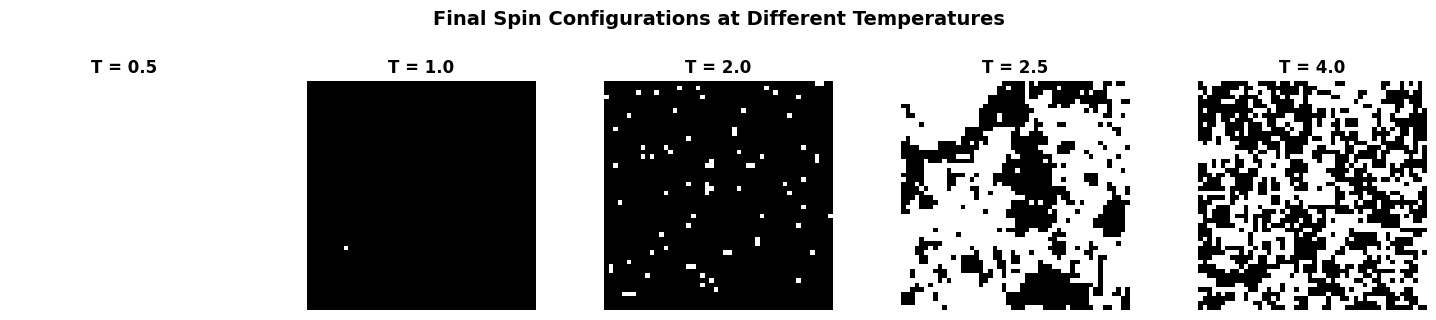

In [8]:
# Create figure with 5 subplots in a row
plt.figure(figsize=(15, 3))

for idx, T in enumerate(temperatures):
    plt.subplot(1, 5, idx + 1)
    
    # Display the spin grid
    # cmap='binary' makes +1 appear white and -1 appear black
    plt.imshow(final_states[T], cmap='binary', vmin=-1, vmax=1)
    
    # Add temperature as title
    plt.title(f"T = {T}", fontsize=12, fontweight='bold')
    
    # Remove axes for cleaner appearance
    plt.axis('off')

# Add overall title
plt.suptitle("Final Spin Configurations at Different Temperatures", 
             fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

### 3.2 Time Evolution at Cold Temperature (T = 0.5)

This visualization shows how the spin system evolves from a random initial state  
to an ordered final state at low temperature. We show snapshots at:  
- 500 steps
- 1500 steps
- 3000 steps
- 5000 steps

In [ ]:
# Choose cold temperature for time evolution study
T_cold = 0.5

print(f"Running simulation at T = {T_cold} and saving snapshots...")

# Create a new random initial configuration
spins_cold = np.random.choice([1, -1], size=(N, N))

# Run simulation and save snapshots at specific steps
final_spins, snapshots = metropolis(
    spins_cold, 
    T_cold, 
    steps=5000,
    save_snapshots=[500, 1500, 3000, 5000]
)

print("Creating time evolution visualization...")

# Create 2×2 grid of snapshots
plt.figure(figsize=(10, 10))

for idx, step in enumerate([500, 1500, 3000, 50000]):
    plt.subplot(2, 2, idx + 1)
    
    # Display the snapshot
    plt.imshow(snapshots[step], cmap='binary', vmin=-1, vmax=1)
    
    # Add step number as title
    plt.title(f"After {step} Steps", fontsize=12, fontweight='bold')
    
    # Remove axes
    plt.axis('off')

# Add overall title
plt.suptitle(f"Time Evolution at T = {T_cold} (Cold Temperature)", 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Running simulation at T = 0.5 and saving snapshots...



### What do we observe at different temperatures?

**At cold temperatures (T = 0.5, 1.0):**  
The system exhibits strong ferromagnetic ordering. Spins strongly prefer to align with their neighbors to minimize energy, creating large uniform regions of white (spin up) or black (spin down). The time evolution shows how random initial conditions gradually organize into these large, ordered domains as the system reaches equilibrium.

**At medium temperatures (T = 2.0, 2.5):**  
We observe a competition between thermal fluctuations and magnetic ordering. The grid shows a mixed pattern with both organized clusters and random regions. Some order persists, but thermal energy is strong enough to disrupt perfect alignment. This intermediate behavior indicates we're near the **critical temperature** where the phase transition occurs.

**At hot temperature (T = 4.0):**  
Thermal energy completely dominates over the ordering tendency. Spins flip randomly and independently, producing a noisy, disordered pattern that resembles television static. No organizational structure is visible because thermal fluctuations are too strong for spins to maintain alignment with their neighbors.

### Where does the phase transition occur?

The transition from the ordered (ferromagnetic) phase to the disordered (paramagnetic) phase occurs somewhere **between T = 1.0 and T = 2.5**. For the 2D Ising model, the exact critical temperature is approximately **T_c ≈ 2.27** (in units where J/k_B = 1). Our simulations clearly show this transition: strong order at T = 1.0, complete disorder at T = 4.0, and mixed behavior at T = 2.0 and T = 2.5.

This phase transition is a beautiful example of **emergent collective behavior**: simple local interactions (spins preferring to align) lead to dramatic macroscopic changes in the system's organization as temperature varies.

## Conclusion

This simulation successfully demonstrates:
1. Implementation of the Metropolis algorithm for the 2D Ising model
2. The dramatic effect of temperature on magnetic ordering
3. The existence of a phase transition from ordered to disordered states
4. How local interactions can lead to global patterns (emergent behavior)

The Ising model, despite its simplicity, captures essential physics of phase transitions and is used to understand phenomena ranging from magnetism to binary alloys to neural networks.